# Imports

In [3]:
import os
import boto3
import numpy as np
import pandas as pd
import tempfile
import xarray as xr
import keras

from huggingface_hub import hf_hub_download
from tornet.data.loader import read_file
from tornet.models.keras.layers import CoordConv2D


print("numpy:", np.__version__)

numpy: 2.4.2


# Access Data

In [4]:
# Setup S3
s3_client = boto3.client('s3')
bucket_name = 'ml-cloud-project-data'

# Download CSV from S3
s3_client.download_file(bucket_name, 'choo_choo_data_3.csv', 'choo_choo_data_3.csv') # choo_choo_data_3.csv is the newest largest training set
df = pd.read_csv('choo_choo_data_3.csv')
print(f"Loaded {len(df)} rows")
print(df.head(2))

# Load pretrained model
model_file = hf_hub_download(
    repo_id="tornet-ml/tornado_detector_baseline_v1",
    filename="tornado_detector_baseline.keras"
)

cnn = keras.models.load_model(
    model_file,
    compile=False,
    custom_objects={"CoordConv2D": CoordConv2D}
)

print("Model inputs:", list(cnn.input.keys()))

# Run inference
variables = ['DBZ', 'VEL']
results = []

def build_model_inputs(data, frame_idx):
    """
    Build the inputs expected by the pretrained TorNet CNN.
    DBZ and VEL come from data, other fields are zero-filled.
    """

    dbz = data["DBZ"][frame_idx]   # (azimuth, range, 2)
    vel = data["VEL"][frame_idx]

    zeros = np.zeros_like(dbz, dtype=np.float32)

    return {
        "DBZ": dbz[np.newaxis],      # add batch dimension
        "VEL": vel[np.newaxis],
        "KDP": zeros[np.newaxis],
        "RHOHV": zeros[np.newaxis],
        "ZDR": zeros[np.newaxis],
        "WIDTH": zeros[np.newaxis],
        "range_folded_mask": zeros[np.newaxis]  # REQUIRED INPUT
    }

def make_coordinates(filepath, frame_idx):
    """Build the coordinates input the model expects from az/range dims"""
    ds = xr.open_dataset(filepath)
    az = ds['azimuth'].values
    rng = ds['range'].values
    
    az_grid, rng_grid = np.meshgrid(az, rng, indexing='ij')

    az_norm = az_grid / 360.0
    rng_norm = rng_grid / 150000.0

    coords = np.stack([az_norm, rng_norm], axis=-1)[np.newaxis].astype(np.float32)
    ds.close()
    return coords


for k, v in cnn.input.items():
    print(k, v.shape)

for _, row in df.iterrows():
    s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
    frame_idx = row['frame_idx']
    
    try:
        with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
            s3_client.download_file(bucket_name, s3_key, tmp.name)

            data = read_file(tmp.name, variables=variables, n_frames=4)
            coords = make_coordinates(tmp.name, frame_idx)
        
        xin = build_model_inputs(data, frame_idx)
        xin["coordinates"] = coords
        
        logit = cnn.predict(xin, verbose=0)
        prob = float(1 / (1 + np.exp(-logit[0, 0])))
        
        results.append({
            'filepath': row['filepath'],
            'event_id': row['event_id'],
            'frame_idx': frame_idx,
            'label': row['label'],
            'tornado_prob': prob
        })

        print(f"✓ {row['event_id']} frame {frame_idx} → prob={prob:.3f}")

    except Exception as e:
        print(f"✗ Failed {row['event_id']} frame {frame_idx}: {e}")
        continue

results_df = pd.DataFrame(results)
results_df.to_csv('pretrained_inference_results.csv', index=False)

# Upload results back to S3
s3_client.upload_file(
    'pretrained_inference_results.csv',
    bucket_name,
    'pretrained_inference_results.csv'
)

print(f"\nDone. {len(results_df)}/{len(df)} succeeded.")

Loaded 756 rows
                                            filepath  \
0  s3://ml-cloud-project-data/tornet_2018/train/2...   
1  s3://ml-cloud-project-data/tornet_2018/train/2...   

                             event_id  frame_idx         label  
0  WRN_180503_081318_KDYX_1080276n_T7          0  non_tornadic  
1  WRN_180503_081318_KDYX_1080276n_T7          1  non_tornadic  

Model inputs: ['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH', 'range_folded_mask', 'coordinates']
DBZ (None, None, None, 2)
VEL (None, None, None, 2)
KDP (None, None, None, 2)
RHOHV (None, None, None, 2)
ZDR (None, None, None, 2)
WIDTH (None, None, None, 2)
range_folded_mask (None, None, None, 2)
coordinates (None, None, None, 2)
✓ WRN_180503_081318_KDYX_1080276n_T7 frame 0 → prob=0.065
✓ WRN_180503_081318_KDYX_1080276n_T7 frame 1 → prob=0.072
✓ WRN_180503_081318_KDYX_1080276n_T7 frame 2 → prob=0.062
✓ WRN_180503_081318_KDYX_1080276n_T7 frame 3 → prob=0.060
✓ NUL_190703_164445_KLTX_845839s_I0 frame 0 → prob=0.122

# With Data Augmentation

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import boto3, tempfile, xarray as xr

# ---------- Step 1: Keep only tornado cases ----------
tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook'])].copy()
tornado_df['binary_label'] = tornado_df['label'].map({
    'tornado_no_hook': 0,
    'tornado_hook': 1
})
print("Class counts:", tornado_df['binary_label'].value_counts())

# ---------- Step 2: Load data from S3 ----------
X_data = []
y_data = []

for _, row in tornado_df.iterrows():
    s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
    frame_idx = row['frame_idx']
    try:
        with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
            s3_client.download_file(bucket_name, s3_key, tmp.name)
            data = read_file(tmp.name, variables=variables, n_frames=4)
            coords = make_coordinates(tmp.name, frame_idx)
        
        xin = build_model_inputs(data, frame_idx)
        xin['coordinates'] = coords
        
        # Remove batch dim for stacking
        X_data.append({k: xin[k][0] for k in xin})
        y_data.append(row['binary_label'])
    except Exception as e:
        print("Failed:", e)
        continue

# Stack inputs for model
X_stacked = {k: np.stack([x[k] for x in X_data]) for k in X_data[0]}
y_data = np.array(y_data)

# ---------- Step 3: Split train/val ----------
indices = np.arange(len(y_data))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=y_data, random_state=42)

X_train = {k: v[train_idx] for k, v in X_stacked.items()}
X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}
y_train = y_data[train_idx]
y_val   = y_data[val_idx]

# ---------- Step 4: Oversample minority class ----------
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
# For oversampling, flatten input dict into single array per sample for ROS
X_flat = np.concatenate([X_train[k].reshape(X_train[k].shape[0], -1) for k in X_train], axis=1)
X_resampled, y_resampled = ros.fit_resample(X_flat, y_train)

# Reshape back into dict of arrays
start = 0
X_train_resampled = {}
for k in X_train:
    n_features = np.prod(X_train[k].shape[1:])
    X_train_resampled[k] = X_resampled[:, start:start+n_features].reshape((-1,) + X_train[k].shape[1:])
    start += n_features

y_train_resampled = y_resampled

# ---------- Step 5: Data augmentation ----------
def augment_batch(batch_dict):
    """Apply safe augmentations for TorNet radar inputs."""
    batch_aug = {}
    for k, x in batch_dict.items():
        # x.shape = (batch, H, W, C)
        x_aug = x.copy()
        # Random horizontal flip
        if np.random.rand() < 0.5:
            x_aug = np.flip(x_aug, axis=2)  # flip width
        # Random vertical flip
        if np.random.rand() < 0.5:
            x_aug = np.flip(x_aug, axis=1)  # flip height
        # Add small Gaussian noise
        noise = np.random.normal(scale=0.01, size=x_aug.shape)
        x_aug = x_aug + noise
        # Clip to valid radar range if needed
        batch_aug[k] = x_aug.astype(np.float32)
    return batch_aug

# Wrap as tf.data.Dataset for efficiency
def generator(X_dict, y):
    while True:
        idx = np.random.permutation(len(y))
        batch_size = 8
        for i in range(0, len(y), batch_size):
            batch_idx = idx[i:i+batch_size]
            X_batch = {k: X_dict[k][batch_idx] for k in X_dict}
            X_batch = augment_batch(X_batch)
            y_batch = y[batch_idx]
            yield (X_batch, y_batch)

train_gen = generator(X_train_resampled, y_train_resampled)
val_gen = generator(X_val, y_val)

steps_per_epoch = len(y_train_resampled) // 8
validation_steps = len(y_val) // 8

# ---------- Step 6: Compile and train ----------
feature_extractor = keras.Model(inputs=cnn.input, outputs=cnn.layers[-2].output)
for layer in feature_extractor.layers[:-15]:
    layer.trainable = False
for layer in feature_extractor.layers[-15:]:
    layer.trainable = True

x = feature_extractor.output
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)
output = keras.layers.Dense(2, activation='softmax')(x)

model = keras.Model(inputs=feature_extractor.input, outputs=output)
model.compile(
    optimizer=keras.optimizers.Adam(3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=40,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

Class counts: binary_label
0    289
1     71
Name: count, dtype: int64
Epoch 1/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 654ms/step - accuracy: 0.4737 - loss: 1.0793 - val_accuracy: 0.2639 - val_loss: 2.4438
Epoch 2/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 617ms/step - accuracy: 0.5154 - loss: 0.9953 - val_accuracy: 0.3889 - val_loss: 1.2014
Epoch 3/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 620ms/step - accuracy: 0.5441 - loss: 0.9270 - val_accuracy: 0.6528 - val_loss: 0.7402
Epoch 4/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 601ms/step - accuracy: 0.5551 - loss: 0.8742 - val_accuracy: 0.7361 - val_loss: 0.6150
Epoch 5/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 603ms/step - accuracy: 0.5132 - loss: 0.8976 - val_accuracy: 0.7917 - val_loss: 0.5434
Epoch 6/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 614ms/step - accuracy: 0.5661 - loss: 0.8362 - val_accuracy: 0.7361 - val_loss: 0.5509
Epoch 7/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 594ms/step - accuracy: 0.5441 - loss: 0.9371 - val_accuracy: 0.7778 - val_loss: 0.4638
Epoch 8/40
57/57 ━━━━━━━━━

## Plot

### Loss

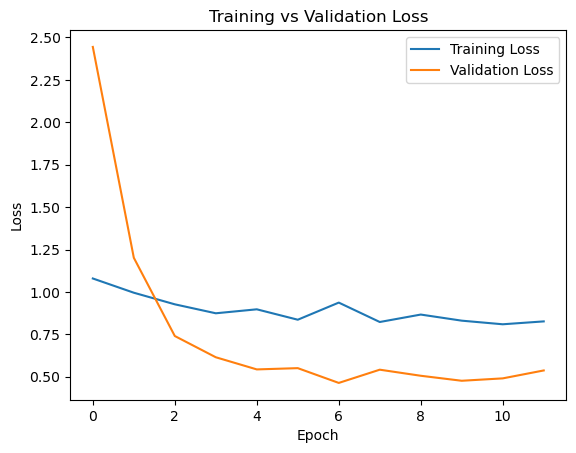

In [7]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

### ROC

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 691ms/step


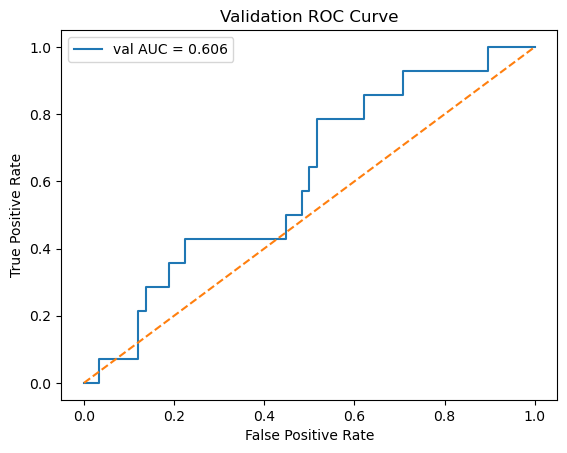

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"val AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()

plt.show()

### Confusion

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 664ms/step


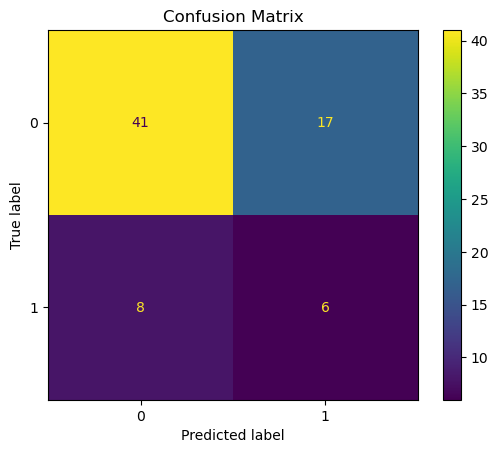

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# predicted class labels
y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [10]:
# Keep only tornado cases
tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook', 'non_tornadic'])].copy()

# Convert to binary labels
tornado_df['binary_label'] = tornado_df['label'].map({
    'tornado_no_hook': 0,
    # 'non_tornadic': 0,
    'tornado_hook': 1
})

print(tornado_df['binary_label'].value_counts())

binary_label
0.0    289
1.0     71
Name: count, dtype: int64


# Old Model

In [55]:
X_data = []
coord_data = []
y_data = []

for _, row in tornado_df.iterrows():
    s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
    frame_idx = row['frame_idx']

    try:
        with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
            s3_client.download_file(bucket_name, s3_key, tmp.name)
            data = read_file(tmp.name, variables=variables, n_frames=4)
            coords = make_coordinates(tmp.name, frame_idx)

        xin = build_model_inputs(data, frame_idx)
        xin["coordinates"] = coords
        
        # Remove batch dimension before storing
        X_data.append({k: xin[k][0] for k in xin})
        y_data.append(row['binary_label'])

    except Exception as e:
        print("Failed:", e)
        continue

# Stack each input separately
X_stacked = {}
for key in X_data[0].keys():
    X_stacked[key] = np.stack([x[key] for x in X_data])

y_data = np.array(y_data)

# display(X_stacked)

In [56]:
from sklearn.model_selection import train_test_split

X_train = {}
X_val = {}

for key in X_stacked:
    X_train[key], X_val[key], y_train, y_val = train_test_split(
        X_stacked[key], y_data,
        test_size=0.2,
        stratify=y_data,
        random_state=42
    )

indices = np.arange(len(y_data))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y_data,
    random_state=42
)

X_train = {k: v[train_idx] for k, v in X_stacked.items()}
X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}

y_train = y_data[train_idx]
y_val   = y_data[val_idx]

feature_extractor = keras.Model(
    inputs=cnn.input,
    outputs=cnn.layers[-2].output
)

# Freeze most layers
for layer in feature_extractor.layers[:-15]:
    layer.trainable = False

# Unfreeze last 15 layers
for layer in feature_extractor.layers[-15:]:
    layer.trainable = True

x = feature_extractor.output

# ADD THIS:
x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
output = keras.layers.Dense(2, activation='softmax')(x)

model = keras.Model(
    inputs=feature_extractor.input,
    outputs=output
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

for i, layer in enumerate(cnn.layers):
    out = layer.output
    
    if isinstance(out, list):
        shape = [o.shape for o in out]
    else:
        shape = out.shape
        
    print(i, layer.name, shape)

0 DBZ (None, None, None, 2)
1 VEL (None, None, None, 2)
2 KDP (None, None, None, 2)
3 RHOHV (None, None, None, 2)
4 ZDR (None, None, None, 2)
5 WIDTH (None, None, None, 2)
6 Normalize_DBZ (None, None, None, 2)
7 Normalize_VEL (None, None, None, 2)
8 Normalize_KDP (None, None, None, 2)
9 Normalize_RHOHV (None, None, None, 2)
10 Normalize_ZDR (None, None, None, 2)
11 Normalize_WIDTH (None, None, None, 2)
12 Concatenate1 (None, None, None, 12)
13 range_folded_mask (None, None, None, 2)
14 Concatenate2 (None, None, None, 14)
15 coordinates (None, None, None, 2)
16 coord_conv2d_20 [(None, None, None, 48), (None, None, None, 2)]
17 coord_conv2d_21 [(None, None, None, 48), (None, None, None, 2)]
18 max_pooling2d_16 (None, None, None, 48)
19 dropout_8 (None, None, None, 48)
20 max_pooling2d_17 (None, None, None, 2)
21 coord_conv2d_22 [(None, None, None, 96), (None, None, None, 2)]
22 coord_conv2d_23 [(None, None, None, 96), (None, None, None, 2)]
23 max_pooling2d_18 (None, None, None, 96)
24 d

In [57]:
import keras

# Remove the last layer (classifier)
feature_extractor = keras.Model(
    inputs=cnn.input,
    outputs=cnn.layers[-2].output
)

for layer in feature_extractor.layers[:-3]: # was 10
    layer.trainable = False

for layer in feature_extractor.layers[-3:]: # was 10
    layer.trainable = True

x = feature_extractor.output

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dense(64, activation='relu')(x) # was 128
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)

output = keras.layers.Dense(2, activation='softmax')(x)

model = keras.Model(
    inputs=feature_extractor.input,
    outputs=output
)

model.compile(
    optimizer=keras.optimizers.Adam(3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(enumerate(weights))

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [59]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=8,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 30s 328ms/step - accuracy: 0.5149 - loss: 1.0137 - val_accuracy: 0.2039 - val_loss: 1.0705
Epoch 2/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 313ms/step - accuracy: 0.5199 - loss: 0.8547 - val_accuracy: 0.3947 - val_loss: 0.8416
Epoch 3/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 299ms/step - accuracy: 0.5281 - loss: 0.9806 - val_accuracy: 0.5789 - val_loss: 0.6566
Epoch 4/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 301ms/step - accuracy: 0.4901 - loss: 0.8625 - val_accuracy: 0.6184 - val_loss: 0.6138
Epoch 5/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 312ms/step - accuracy: 0.4884 - loss: 0.9191 - val_accuracy: 0.7434 - val_loss: 0.5602
Epoch 6/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 299ms/step - accuracy: 0.5116 - loss: 0.8426 - val_accuracy: 0.7829 - val_loss: 0.5588
Epoch 7/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 298ms/step - accuracy: 0.4570 - loss: 0.8540 - val_accuracy: 0.8816 - val_loss: 0.5509
Epoch 8/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 297ms/step - accuracy: 0.5083 - loss: 0.7671 - val_accu

In [60]:
# print(type(cnn))
# cnn.summary()

In [61]:
print("Train hook fraction:", np.mean(y_train))
print("Val hook fraction:", np.mean(y_val))

Train hook fraction: 0.09437086092715231
Val hook fraction: 0.09210526315789473


## Plot

### Training vs Validation

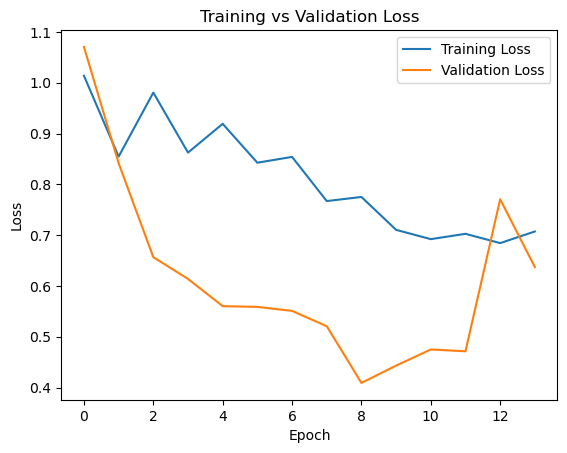

In [62]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

### ROC

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 929ms/step


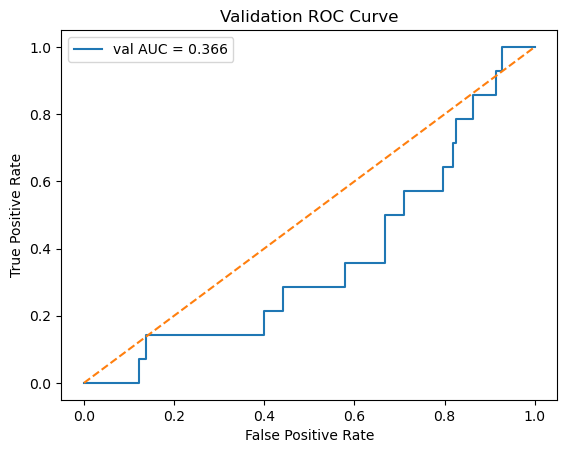

In [63]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"val AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()

plt.show()

### Confusion Matrix

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 855ms/step


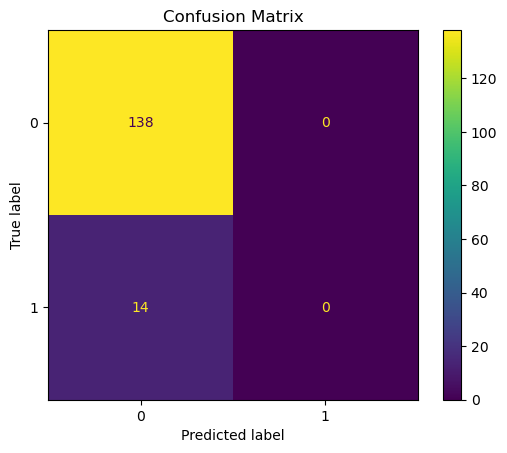

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# predicted class labels
y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

# NEW TRY

In [ ]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):

    def loss(y_true, y_pred):
        # Clip predictions for numerical stability
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # Cross entropy
        bce = -(y_true * tf.math.log(y_pred) +
                (1 - y_true) * tf.math.log(1 - y_pred))

        # Focal scaling
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow((1 - p_t), gamma)

        return focal_weight * bce

    return loss

In [ ]:
import tensorflow as tf
from tensorflow import keras

# ── Inputs: only DBZ and VEL (2 channels each) ──────────────────────────────
dbz_input = keras.Input(shape=(None, None, 2), name='DBZ')
vel_input  = keras.Input(shape=(None, None, 2), name='VEL')

# ── Normalize ────────────────────────────────────────────────────────────────
dbz_norm = keras.layers.Normalization(name='Normalize_DBZ')(dbz_input)
vel_norm  = keras.layers.Normalization(name='Normalize_VEL')(vel_input)

# ── Concatenate (4 channels total instead of 14) ─────────────────────────────
x = keras.layers.Concatenate(name='Concatenate1')([dbz_norm, vel_norm])

# ── Replace NaNs with 0 ──────────────────────────────────────────────────────
x = keras.layers.ZeroPadding2D(padding=0)(x)  # no-op, just skip the nan line

# ── Conv block 1: 48 filters ─────────────────────────────────────────────────
x = keras.layers.Conv2D(48, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(48, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.2)(x)

# ── Conv block 2: 96 filters ─────────────────────────────────────────────────
x = keras.layers.Conv2D(96, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(96, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.2)(x)

# ── Conv block 3: 192 filters ────────────────────────────────────────────────
x = keras.layers.Conv2D(192, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(192, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(192, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.2)(x)

# ── Conv block 4: 384 filters ────────────────────────────────────────────────
x = keras.layers.Conv2D(384, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(384, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(384, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.2)(x)

# ── Classification head ───────────────────────────────────────────────────────
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.4)(x)
output = keras.layers.Dense(1, activation='sigmoid', name='hook')(x)

model = keras.Model(inputs=[dbz_input, vel_input], outputs=output)

# model.compile(
#     optimizer=keras.optimizers.Adam(1e-4), # original was 1e-4, trying to lower learning rate for the transfer learning. Tried 1e-5 and 1e-6
#     loss='binary_crossentropy',    # sigmoid + binary is better than softmax + sparse_categorical for 2-class
#     metrics=['accuracy', keras.metrics.AUC(name='auc')]
# )

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ DBZ (InputLayer)    │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ VEL (InputLayer)    │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_DBZ       │ (None, None,      │          5 │ DBZ[0][0]         │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_VEL       │ (None, None,      │          5 │ VEL[0][0]         │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate1        │ (None, None,      │          0 │ Normalize_DBZ[0]… │
│ (Concatenate)       │ None, 4)          │            │ Normalize_VEL[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_6    │ (None, None,      │          0 │ Concatenate1[0][… │
│ (ZeroPadding2D)     │ None, 4)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, None,      │      1,776 │ zero_padding2d_6… │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, None,      │     20,784 │ conv2d_80[0][0]   │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, None,      │          0 │ conv2d_81[0][0]   │
│ (MaxPooling2D)      │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, None,      │          0 │ max_pooling2d_24… │
│ (Dropout)           │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, None,      │     41,568 │ dropout_33[0][0]  │
│                     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, None,      │     83,040 │ conv2d_82[0][0]   │
│                     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_25    │ (None, None,      │          0 │ conv2d_83[0][0]   │
│ (MaxPooling2D)      │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, None,      │          0 │ max_pooling2d_25… │
│ (Dropout)           │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, None,      │    166,080 │ dropout_34[0][0]  │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, None,      │    331,968 │ conv2d_84[0][0]   │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, None,      │    331,968 │ conv2d_85[0][0] 

 Total params: 4,346,027 (16.58 MB)

 Trainable params: 4,345,761 (16.58 MB)

 Non-trainable params: 266 (1.05 KB)

In [ ]:
X_train_dbz = X_train['DBZ']
X_train_vel  = X_train['VEL']
X_val_dbz   = X_val['DBZ']
X_val_vel    = X_val['VEL']

# Handle NaNs before training
X_train_dbz = np.nan_to_num(X_train_dbz, nan=0.0)
X_train_vel  = np.nan_to_num(X_train_vel,  nan=0.0)
X_val_dbz   = np.nan_to_num(X_val_dbz,   nan=0.0)
X_val_vel   = np.nan_to_num(X_val_vel,   nan=0.0)

## Train only the Head

In [ ]:
print(X_train.keys())

dict_keys(['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH', 'range_folded_mask', 'coordinates'])


In [ ]:
for layer in model.layers:
    if isinstance(layer, keras.layers.Conv2D):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [ ]:
history1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=8,
    class_weight=class_weight
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 284ms/step - accuracy: 0.5035 - auc: 0.5744 - loss: 0.0721 - val_accuracy: 0.2639 - val_auc: 0.5308 - val_loss: 0.0445
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.5139 - auc: 0.4372 - loss: 0.0843 - val_accuracy: 0.3056 - val_auc: 0.5197 - val_loss: 0.0443
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.4618 - auc: 0.4703 - loss: 0.0750 - val_accuracy: 0.7500 - val_auc: 0.5191 - val_loss: 0.0417
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.4097 - auc: 0.3702 - loss: 0.0783 - val_accuracy: 0.6389 - val_auc: 0.5049 - val_loss: 0.0422
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 269ms/step - accuracy: 0.5000 - auc: 0.5044 - loss: 0.0790 - val_accuracy: 0.8056 - val_auc: 0.5369 - val_loss: 0.0400
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 272ms/step - accuracy: 0.5347 - auc: 0.4628 - loss: 0.0821 - val_accuracy: 0.7222 - val_auc: 0.4889 - val_loss: 0.0407
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━

## Fine-tune upper layers

In [ ]:
for layer in model.layers:
    layer.trainable = True

# Freeze early layers again
for layer in model.layers[:-10]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-6),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [ ]:
history2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8,
    class_weight=class_weight
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 428ms/step - accuracy: 0.4965 - auc: 0.5623 - loss: 0.0570 - val_accuracy: 0.8056 - val_auc: 0.5554 - val_loss: 0.0327
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 383ms/step - accuracy: 0.4514 - auc: 0.4661 - loss: 0.0624 - val_accuracy: 0.8056 - val_auc: 0.5468 - val_loss: 0.0328
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 414ms/step - accuracy: 0.5139 - auc: 0.5610 - loss: 0.0614 - val_accuracy: 0.8056 - val_auc: 0.5308 - val_loss: 0.0337
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 409ms/step - accuracy: 0.4965 - auc: 0.4904 - loss: 0.0684 - val_accuracy: 0.8056 - val_auc: 0.5320 - val_loss: 0.0334
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 427ms/step - accuracy: 0.4896 - auc: 0.5508 - loss: 0.0587 - val_accuracy: 0.8056 - val_auc: 0.5357 - val_loss: 0.0344
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 405ms/step - accuracy: 0.5069 - auc: 0.4907 - loss: 0.0604 - val_accuracy: 0.8056 - val_auc: 0.5413 - val_loss: 0.0354
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━

## Use AUC for early stopping

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=7,
    restore_best_weights=True
)

## old running model

In [ ]:
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weight = {0: weights[0], 1: weights[1]}

# early_stop = keras.callbacks.EarlyStopping(
#     monitor='val_auc', mode='max', patience=7, restore_best_weights=True
# )

# history = model.fit(
#     {'DBZ': X_train_dbz, 'VEL': X_train_vel},  # separate arrays per input
#     y_train,
#     validation_data=(
#         {'DBZ': X_val_dbz, 'VEL': X_val_vel},
#         y_val
#     ),
#     epochs=50,
#     batch_size=8,
#     class_weight=class_weight,
#     callbacks=[early_stop]
# )

## Plots

### Training vs Validation Loss Curve

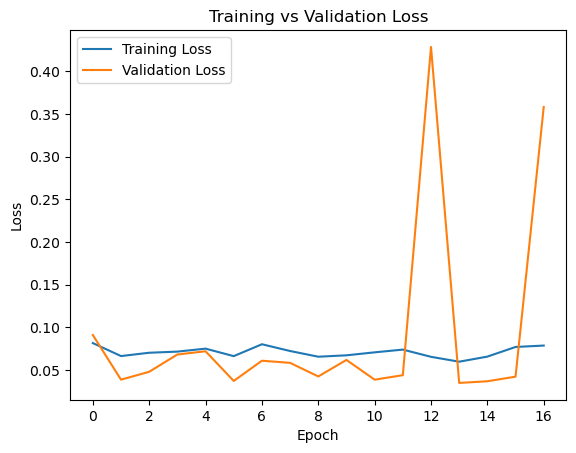

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

### ROC

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step


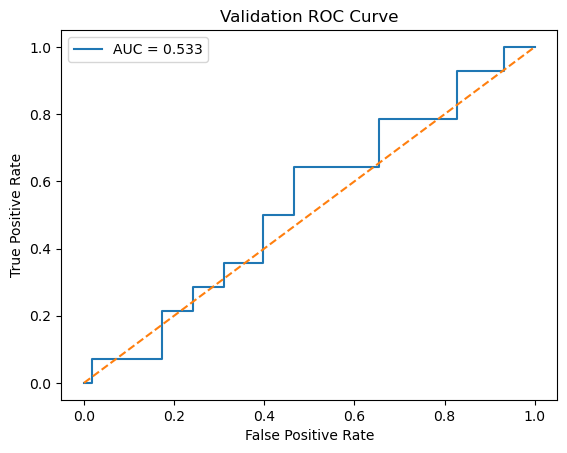

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_val).ravel()

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()

plt.show()

### Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step


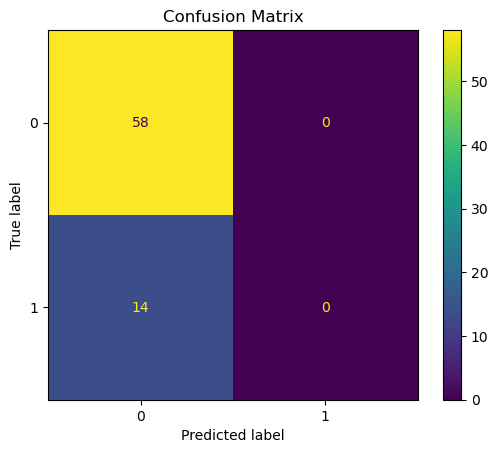

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# predicted class labels
y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.89        58
           1       0.00      0.00      0.00        14

    accuracy                           0.81        72
   macro avg       0.40      0.50      0.45        72
weighted avg       0.65      0.81      0.72        72


c:\Users\abchu\miniforge3\envs\MLtornado_model\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\abchu\miniforge3\envs\MLtornado_model\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\abchu\miniforge3\envs\MLtornado_model\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri